In [1]:
import os
import glob

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
files = glob.glob('./dataview/*.xlsx')
files = [file for file in files if 'CoT' not in file]

scenario_map = {
    'binary-tree': 'Binary Tree',
    'multiple-tree': 'Multiple Tree',
    'JSON': 'JSON',
    'formula': 'Formula',
    'code': 'Code',
    'paper': 'Paper'
}

dfs = dict()
for file in files:
    scenario = scenario_map[os.path.basename(file).rstrip('.xlsx')]
    try:
        dfs[scenario] = pd.read_excel(file, sheet_name='Difficulty')
    except ValueError:
        try:
            dfs[scenario] = pd.read_excel(file, sheet_name='Length')
            dfs[scenario] = dfs[scenario].rename(columns={'Length': 'Difficulty'})
        except ValueError:
            continue
    # combine difficulty in JSON
    if 'JSON' in file:
        df = dfs[scenario]
        difficulty_mapping = {
            'large-1': 'hard', 'large-2': 'hard',
            'medium-1': 'medium', 'medium-2': 'medium',
            'small': 'easy'
        }
        df['Difficulty'] = df['Difficulty'].map(difficulty_mapping).fillna(df['Difficulty'])
        df_combined = df.groupby('Difficulty').agg({
            'mean': 'mean',
            'std': 'mean',
            'count': 'sum'
        }).reset_index()
        dfs[scenario] = df_combined
dfs

{'JSON':   Difficulty       mean        std  count
 0       easy  48.019749  41.731758    398
 1       hard  37.029758  37.526739    795
 2     medium  39.144225  38.803651    797,
 'Multiple Tree':   Difficulty       mean        std  count
 0       easy  46.563880  32.785696    366
 1       hard  41.405042  31.788462    361
 2     medium  45.710937  32.312255    363,
 'Binary Tree':   Difficulty       mean        std  count
 0       easy  48.081688  35.676319    480
 1       hard  19.603943  29.467946    454
 2     medium  31.766833  33.375868    480,
 'Formula':   Difficulty       mean        std  count
 0       easy  47.867185  32.239239   3240
 1       hard  38.148457  32.636810   3240
 2     medium  41.423404  33.211553   3240}

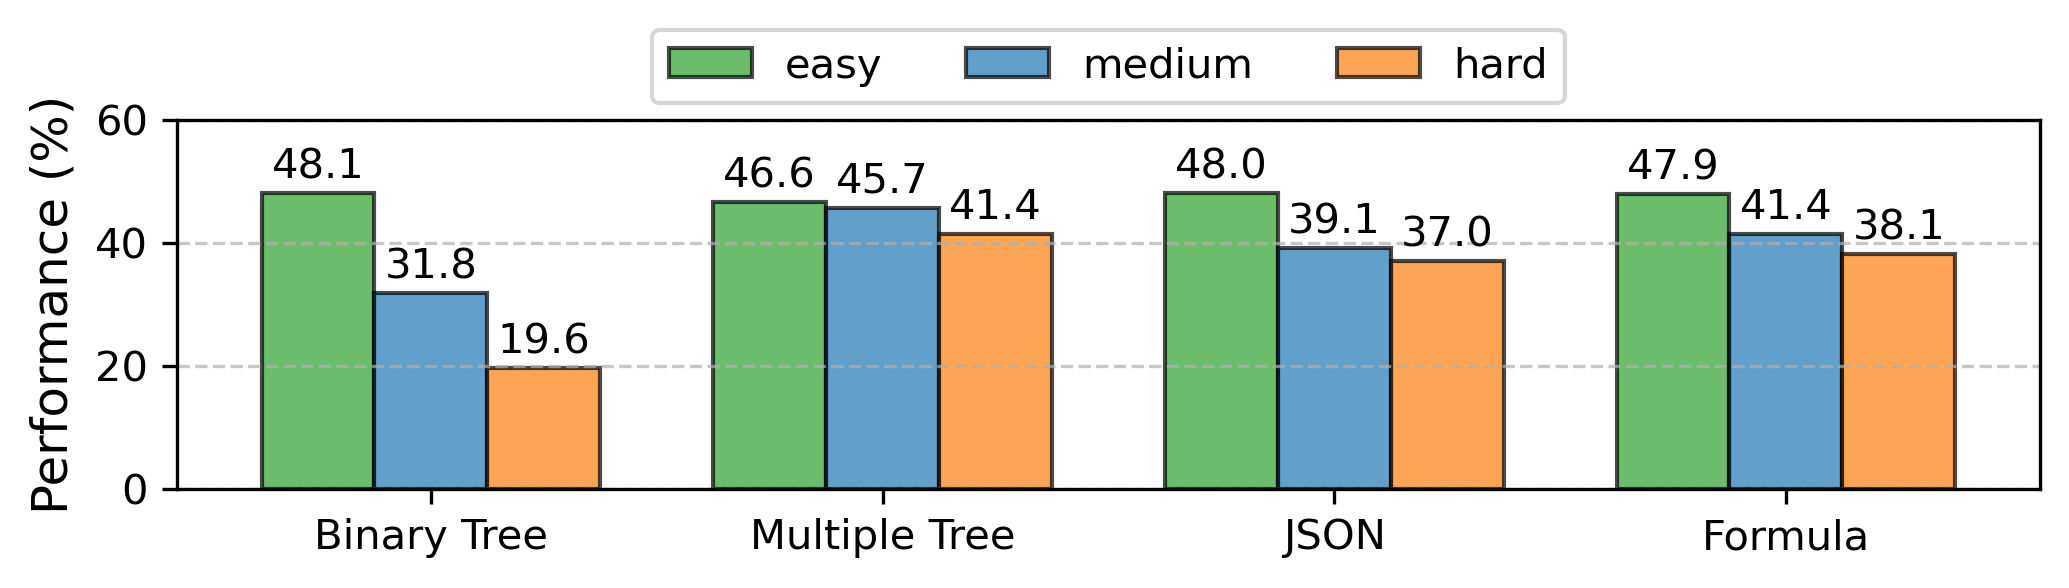

In [15]:
difficulty_order = ['easy', 'medium', 'hard']
colors = {'easy': '#2ca02c', 'medium': '#1f77b4', 'hard': '#ff7f0e'}
scenario_order = ['Binary Tree', 'Multiple Tree', 'JSON', 'Formula']


fig, ax = plt.subplots(figsize=(7, 2.2), dpi=300)

bar_width = 0.25
index = range(len(scenario_order))

for i, scenario in enumerate(scenario_order):
    df = dfs[scenario]
    filtered_data = df[df['Difficulty'].isin(difficulty_order)]
    filtered_data = filtered_data.set_index('Difficulty').reindex(difficulty_order).reset_index()

    bars = []
    for j, difficulty in enumerate(difficulty_order):
        difficulty_data = filtered_data[filtered_data['Difficulty'] == difficulty]
        bar = ax.bar(
            index[i] + bar_width * j, difficulty_data['mean'].values[0], 
            color=colors[difficulty], width=bar_width, alpha=0.7, label=difficulty if i == 0 else "")
        bars.append(bar)

    for bar in bars:
        for rect in bar:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2, height + 1, f'{height:.1f}', 
                    ha='center', va='bottom', fontsize=10)

for bar in ax.patches:
    bar.set_edgecolor('black')
    bar.set_linewidth(1)
    
ax.set_ylabel('Performance (%)', fontsize=12)
ax.set_xticks([i + bar_width for i in index])
ax.set_xticklabels(scenario_order)
ax.set_ylim(0, 60)

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='', bbox_to_anchor=(0.5, 1.3), loc='upper center', ncol=3)

plt.tight_layout()
plt.savefig('../Images/structure-complexity.pdf')